## Figure 7 - Long-term health and climate indicators for the Lower Tocantins region
<hr style="border:1px solid #274ad4;">


In [1]:
# Accessing health data from Harmonize-ds package
# Installing the harmonize-ds package
import importlib
from importlib import metadata

pkg = "harmonize-ds"
module_name = "harmonize_ds"

try:
    harmonize_ds = importlib.import_module(module_name)
except ImportError:
    # em notebook:
    !pip install -U git+https://github.com/Harmonize-Brazil/harmonize-ds.git@v0.1.0
    harmonize_ds = importlib.import_module(module_name)

# version: tenta pelo módulo, senão via metadata do pacote instalado
ver = getattr(harmonize_ds, "__version__", None) or metadata.version(pkg)
print("HarmonizeDS:", ver)

HarmonizeDS: 0.4.0


In [4]:
# Installing additional libraries for processing and visualization:
import importlib
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.cm as cm

plt.style.use("ggplot")

for module in ["rasterio","shapely","matplotlib","geopandas","tqdm","folium"]:
    try:
        importlib.import_module(module)
        print(f"OK: {module}")
    except ImportError:
        !pip install -U {module}
        print(f"INSTALADO: {module}")


OK: rasterio
OK: shapely
OK: matplotlib
OK: geopandas
OK: tqdm
OK: folium


In [5]:
## Configure the HARMONIZE Health GeoServer and list the available data collections
from harmonize_ds import HARMONIZEDS

for ds in HARMONIZEDS.manager.get_datasources():
    if ds._source_id == "bdc_lcc-wfs":
        ds._url = "https://geolab.inpe.br/big/geoserver/harmonize_health"

print("Available collections:")

for collection in HARMONIZEDS.collections():
    print(collection)

Available collections:
{'id': 'bdc_lcc-wfs', 'collection': 'harmonize_health:chagas_disease_incidence_NE_mun_month_lis'}
{'id': 'bdc_lcc-wfs', 'collection': 'harmonize_health:chagas_disease_incidence_NO_mun_month_lis'}
{'id': 'bdc_lcc-wfs', 'collection': 'harmonize_health:chikungunya_alert_level_NE_mun_epiweek_infodengue'}
{'id': 'bdc_lcc-wfs', 'collection': 'harmonize_health:chikungunya_alert_level_NO_mun_epiweek_infodengue'}
{'id': 'bdc_lcc-wfs', 'collection': 'harmonize_health:chikungunya_cases_notified_NE_mun_epiweek_infodengue'}
{'id': 'bdc_lcc-wfs', 'collection': 'harmonize_health:chikungunya_cases_notified_NO_mun_epiweek_infodengue'}
{'id': 'bdc_lcc-wfs', 'collection': 'harmonize_health:chikungunya_confirmed_cases_NE_mun_epiweek_infodengue'}
{'id': 'bdc_lcc-wfs', 'collection': 'harmonize_health:chikungunya_confirmed_cases_NO_mun_epiweek_infodengue'}
{'id': 'bdc_lcc-wfs', 'collection': 'harmonize_health:chikungunya_incidence_NE_mun_epiweek_infodengue'}
{'id': 'bdc_lcc-wfs', 'coll

In [6]:
# Define the data for the charts
collections_selected = [
    "harmonize_health:dengue_cases_NO_mun_epiweek_infodengue",
    "harmonize_health:dengue_incidence_NO_mun_epiweek_infodengue"
]

In [ ]:
# Dengue cases 
# Retrieve dengue case data convert it to a pandas DataFrame

service_id = "bdc_lcc-wfs"
collection = "harmonize_health:dengue_cases_NO_mun_epiweek_infodengue"

cl = HARMONIZEDS.get_collection(service_id, collection)

gdf = cl.get(filter={"epiweek_start_date": date_range}, srid=4326)  # retorna GeoDataFrame

df_dengue_cases = pd.DataFrame(gdf).copy()

/Users/anapdalasta/Desktop/@na_Dados/scripts/venv/lib/python3.12/site-packages/rich/live.py:231: UserWarning: 
install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

[14:15:58] ⚠ Finishing...                                                                                ]8;id=62410;file:///Users/anapdalasta/Desktop/@na_Dados/scripts/venv/lib/python3.12/site-packages/harmonize_ds/sources/wfs.py\wfs.py]8;;\:]8;id=703009;file:///Users/anapdalasta/Desktop/@na_Dados/scripts/venv/lib/python3.12/site-packages/harmonize_ds/sources/wfs.py#234\234]8;;\

[14:16:03] ✅ Total features received: 17840                                                             ]8;id=454480;file:///Users/anapdalasta/Desktop/@na_Dados/scripts/venv/lib/python3.12/site-packages/harmonize_ds/sources/wfs.py\wfs.py]8;;\:]8;id=257750;file:///Users/anapdalasta/Desktop/@na_Dados/scripts/venv/lib/python3.12/site-packages/harmonize_ds/sources/wfs.py#287\287]8;;\

In [39]:
# Define the municipalities of the interest and their corresponding IBGE codes
name_mun = {
    "1502103": "Cametá",
    "1504604": "Mocajuba"
}

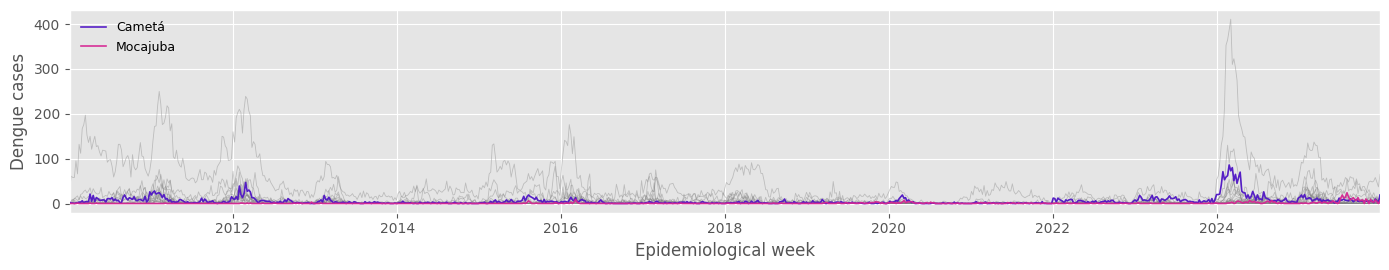

In [40]:
# Prepare dengue case data and create the time-series chart

df_dengue_cases_plot1 = df_dengue_cases.copy()

df_dengue_cases_plot1["epiweek_start_date"] = pd.to_datetime(df_dengue_cases_plot1["epiweek_start_date"], errors="coerce")
df_dengue_cases_plot1["value"] = pd.to_numeric(df_dengue_cases_plot1["value"], errors="coerce")

df_dengue_cases_plot1 = (
    df_dengue_cases_plot1.dropna(subset=["epiweek_start_date", "value", "cod_mun"])
            .sort_values(["cod_mun", "epiweek_start_date"])
)

fig, ax = plt.subplots(figsize=(14, 2.8))

for cod, dfi in df_dengue_cases_plot1.groupby("cod_mun", sort=False):
    ax.plot(
        dfi["epiweek_start_date"],
        dfi["value"],
        color="gray",
        linewidth=0.6,   
        alpha=0.4,      
        zorder=1
    )


highlight_codes = ["1502103", "1504604"]
colors = {
    "1502103": "#5016c6",
    "1504604": "#d62793"
}

for cod in highlight_codes:
    dfi = df_dengue_cases_plot1[df_dengue_cases_plot1["cod_mun"] == cod]
    ax.plot(
        dfi["epiweek_start_date"],
        dfi["value"],
        color=colors[cod],
        linewidth=1.2,   
        alpha=0.95,
        label=name_mun.get(cod, str(cod)), 
        zorder=3
    )

ax.set_xlabel("Epidemiological week")
ax.set_ylabel("Dengue cases")
ax.legend(
    frameon=False,
    loc="upper left",
    fontsize=9
)
ax.margins(x=0)
fig.tight_layout()
plt.show()


In [ ]:
# Dengue incidence
# Retrieve dengue incidence data and convert it to a pandas DataFrame

collection = "harmonize_health:dengue_incidence_NO_mun_epiweek_infodengue"

cl = HARMONIZEDS.get_collection(service_id, collection)

gdf = cl.get(filter={"epiweek_start_date": date_range}, srid=4326)  

df_dengue_incidence = pd.DataFrame(gdf).copy()

/Users/anapdalasta/Desktop/@na_Dados/scripts/venv/lib/python3.12/site-packages/rich/live.py:231: UserWarning: 
install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

[10:29:11] ⚠ Finishing...                                                                                ]8;id=943239;file:///Users/anapdalasta/Desktop/@na_Dados/scripts/venv/lib/python3.12/site-packages/harmonize_ds/sources/wfs.py\wfs.py]8;;\:]8;id=304639;file:///Users/anapdalasta/Desktop/@na_Dados/scripts/venv/lib/python3.12/site-packages/harmonize_ds/sources/wfs.py#234\234]8;;\

[10:29:16] ✅ Total features received: 17950                                                             ]8;id=827049;file:///Users/anapdalasta/Desktop/@na_Dados/scripts/venv/lib/python3.12/site-packages/harmonize_ds/sources/wfs.py\wfs.py]8;;\:]8;id=19177;file:///Users/anapdalasta/Desktop/@na_Dados/scripts/venv/lib/python3.12/site-packages/harmonize_ds/sources/wfs.py#287\287]8;;\

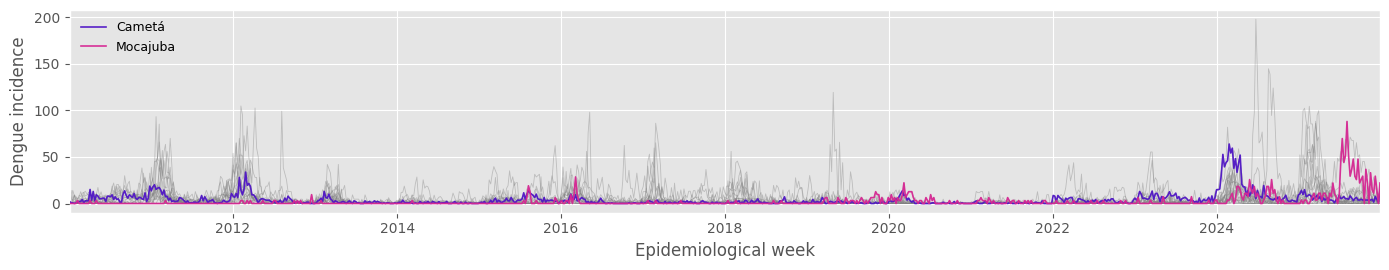

In [24]:
# Prepare dengue case data and create the time-series chart

df_dengue_incidence_plot1 = df_dengue_incidence.copy()

df_dengue_incidence_plot1["epiweek_start_date"] = pd.to_datetime(df_dengue_incidence_plot1["epiweek_start_date"], errors="coerce")
df_dengue_incidence_plot1["value"] = pd.to_numeric(df_dengue_incidence_plot1["value"], errors="coerce")

df_dengue_incidence_plot1 = (
    df_dengue_incidence_plot1.dropna(subset=["epiweek_start_date", "value", "cod_mun"])
            .sort_values(["cod_mun", "epiweek_start_date"])
)

fig, ax = plt.subplots(figsize=(14, 2.8))

for cod, dfi in df_dengue_incidence_plot1.groupby("cod_mun", sort=False):
    ax.plot(
        dfi["epiweek_start_date"],
        dfi["value"],
        color="gray",
        linewidth=0.6,   
        alpha=0.4,      
        zorder=1
    )


highlight_codes = ["1502103", "1504604"]
colors = {
    "1502103": "#5016c6",
    "1504604": "#d62793"
}

for cod in highlight_codes:
    dfi = df_dengue_incidence_plot1[df_dengue_incidence_plot1["cod_mun"] == cod]
    ax.plot(
        dfi["epiweek_start_date"],
        dfi["value"],
        color=colors[cod],
        linewidth=1.2,   
        alpha=0.95,
        label=name_mun.get(cod, str(cod)), 
        zorder=3
    )

ax.set_xlabel("Epidemiological week")
ax.set_ylabel("Dengue incidence")
ax.legend(
    frameon=False,
    loc="upper left",
    fontsize=9
)
ax.margins(x=0)
fig.tight_layout()
plt.show()


### Charts with climate data from .csv file
  

All climate data used in these charts are available in the HARMONIZE Project repository:

**Mean temperature:**  
https://geolab.inpe.br/bdc/harmonize/stac/v1/collections/temperature_mean_no_mun_epiweek_era5land-1

**Humidity:**  
https://geolab.inpe.br/bdc/harmonize/stac/v1/collections/humidity_percent_no_mun_epiweek_era5land-1

**Maximum precipitation:**  
https://geolab.inpe.br/bdc/harmonize/stac/v1/collections/precip_max_no_mun_epiweek_era5land-1


In [7]:
# Import and load the mean temperature data from CSV file 

path = "/Volumes/Expansion/2026/Harmonize_reports/Artigo_Maciel_etal/temp_mean_no_mun_epiweek_era5land-1.csv"

df_temp_mean = pd.read_csv(path)

In [8]:
# Display the column names and available in the dataset
df_temp_mean.columns

Index(['cod_mun', 'name_mun', 'uf_mun', 'data_source', 'name_indicator',
       'epiweek_number', 'epiweek_start_date', 'time_agg', 'spatial_agg',
       'value', 'year_month'],
      dtype='object')

In [10]:
# Define the municipalities of the interest and their corresponding IBGE codes
mun_names = {
    1502103: "Cametá",
    1504604: "Mocajuba"
}

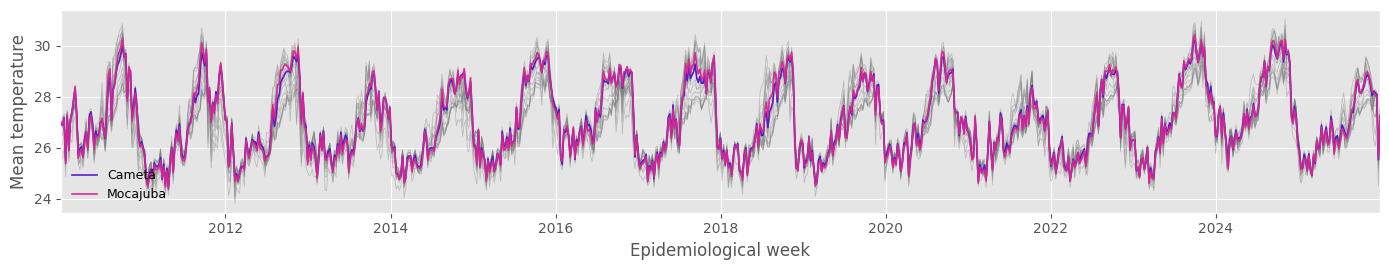

In [11]:
# Prepare mean temperature data and create the time-series chart

df_temp_plot1 = df_temp_mean.copy()

df_temp_plot1["date"] = pd.to_datetime(df_temp_plot1["epiweek_start_date"], errors="coerce")
df_temp_plot1["value"] = pd.to_numeric(df_temp_plot1["value"], errors="coerce")

df_temp_plot1 = (
    df_temp_plot1.dropna(subset=["date", "value", "cod_mun"])
            .sort_values(["cod_mun", "date"])
)

fig, ax = plt.subplots(figsize=(14, 2.8))

for cod, dfi in df_temp_plot1.groupby("cod_mun", sort=False):
    ax.plot(
        dfi["date"],
        dfi["value"],
        color="gray",
        linewidth=0.6,   
        alpha=0.4,      
        zorder=1
    )

highlight_codes = [1502103, 1504604]
colors = {1502103: "#5016c6", 1504604: "#d62793"}

for cod in highlight_codes:
    dfi = df_temp_plot1[df_temp_plot1["cod_mun"] == cod]
    ax.plot(
        dfi["date"],
        dfi["value"],
        color=colors[cod],
        linewidth=1.2,   
        alpha=0.95,
        label=mun_names.get(cod, str(cod)), 
        zorder=3
    )

ax.set_xlabel("Epidemiological week")
ax.set_ylabel("Mean temperature")
ax.legend(
    frameon=False,
    loc="lower left",
    fontsize=9
)
ax.margins(x=0)
fig.tight_layout()
plt.show()


In [12]:
# Import and load the relative humidity data from CSV file 

path = "/Volumes/Expansion/2026/Harmonize_reports/Artigo_Maciel_etal/humidity_percent_no_mun_epiweek_era5land-1.csv"

df_humidity = pd.read_csv(path)

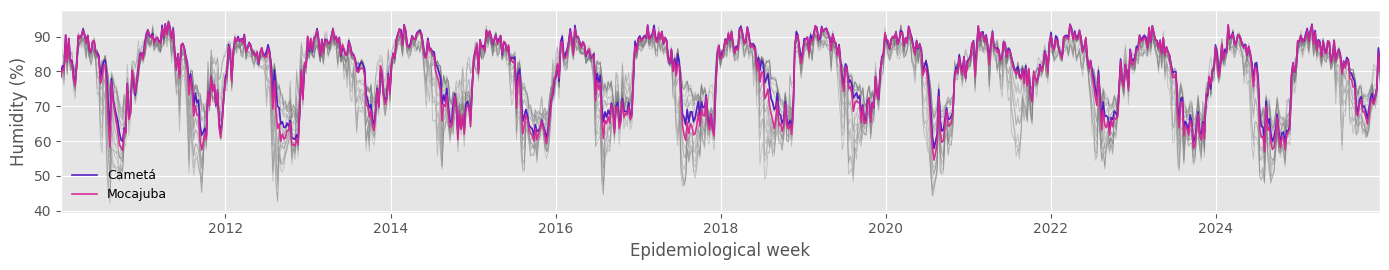

In [13]:
# Prepare relative humidity data and create the time-series chart

df_humidity_plot1 = df_humidity.copy()

df_humidity_plot1["date"] = pd.to_datetime(df_humidity_plot1["epiweek_start_date"], errors="coerce")
df_humidity_plot1["value"] = pd.to_numeric(df_humidity_plot1["value"], errors="coerce")

df_humidity_plot1 = (
    df_humidity_plot1.dropna(subset=["date", "value", "cod_mun"])
            .sort_values(["cod_mun", "date"])
)

fig, ax = plt.subplots(figsize=(14, 2.8))


for cod, dfi in df_humidity_plot1.groupby("cod_mun", sort=False):
    ax.plot(
        dfi["date"],
        dfi["value"],
        color="gray",
        linewidth=0.6,  
        alpha=0.4,      
        zorder=1
    )

highlight_codes = [1502103, 1504604]
colors = {1502103: "#5016c6", 1504604: "#d62793"}

for cod in highlight_codes:
    dfi = df_humidity_plot1[df_humidity_plot1["cod_mun"] == cod]
    ax.plot(
        dfi["date"],
        dfi["value"],
        color=colors[cod],
        linewidth=1.2,  
        alpha=0.95,
        label=mun_names.get(cod, str(cod)), 
        zorder=3
    )

ax.set_xlabel("Epidemiological week")
ax.set_ylabel("Humidity (%)")
ax.legend(
    frameon=False,
    loc="lower left",
    fontsize=9
)
ax.margins(x=0)
fig.tight_layout()
plt.show()

In [14]:
# Import and load the maximum precipitation data from CSV file 

path = "/Volumes/Expansion/2026/Harmonize_reports/Artigo_Maciel_etal/precip_max_no_mun_epiweek_era5land-1.csv"

df_precip_max = pd.read_csv(path)

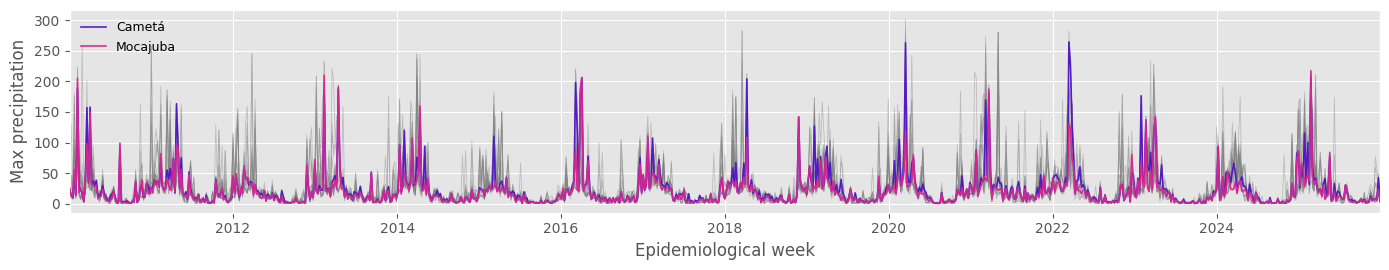

In [18]:
# Prepare relative humidity data and create the time-series chart

df_precip_plot1 = df_precip_max.copy()

df_precip_plot1["date"] = pd.to_datetime(df_precip_plot1["epiweek_start_date"], errors="coerce")
df_precip_plot1["value"] = pd.to_numeric(df_precip_plot1["value"], errors="coerce")

df_precip_plot1 = (
    df_precip_plot1.dropna(subset=["date", "value", "cod_mun"])
            .sort_values(["cod_mun", "date"])
)

fig, ax = plt.subplots(figsize=(14, 2.8))

for cod, dfi in df_precip_plot1.groupby("cod_mun", sort=False):
    ax.plot(
        dfi["date"],
        dfi["value"],
        color="gray",
        linewidth=0.6,   
        alpha=0.4,      
        zorder=1
    )

highlight_codes = [1502103, 1504604]
colors = {1502103: "#5016c6", 1504604: "#d62793"}

for cod in highlight_codes:
    dfi = df_precip_plot1[df_precip_plot1["cod_mun"] == cod]
    ax.plot(
        dfi["date"],
        dfi["value"],
        color=colors[cod],
        linewidth=1.2,   
        alpha=0.95,
        label=mun_names.get(cod, str(cod)), 
        zorder=3
    )

ax.set_xlabel("Epidemiological week")
ax.set_ylabel("Max precipitation")
ax.legend(
    frameon=False,
    loc="upper left",
    fontsize=9
)
ax.margins(x=0)
fig.tight_layout()
plt.show()
